In [1]:
import os
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

## Data Generation Pipeline

#### Sampling DAGs based on family

In [4]:
from synthetic.structure import *
from synthetic.binary import *

er | edges: 28 | max_in: 2 | max_out: 2
ba | edges: 30 | max_in: 2 | max_out: 2
small-world | edges: 31 | max_in: 2 | max_out: 2


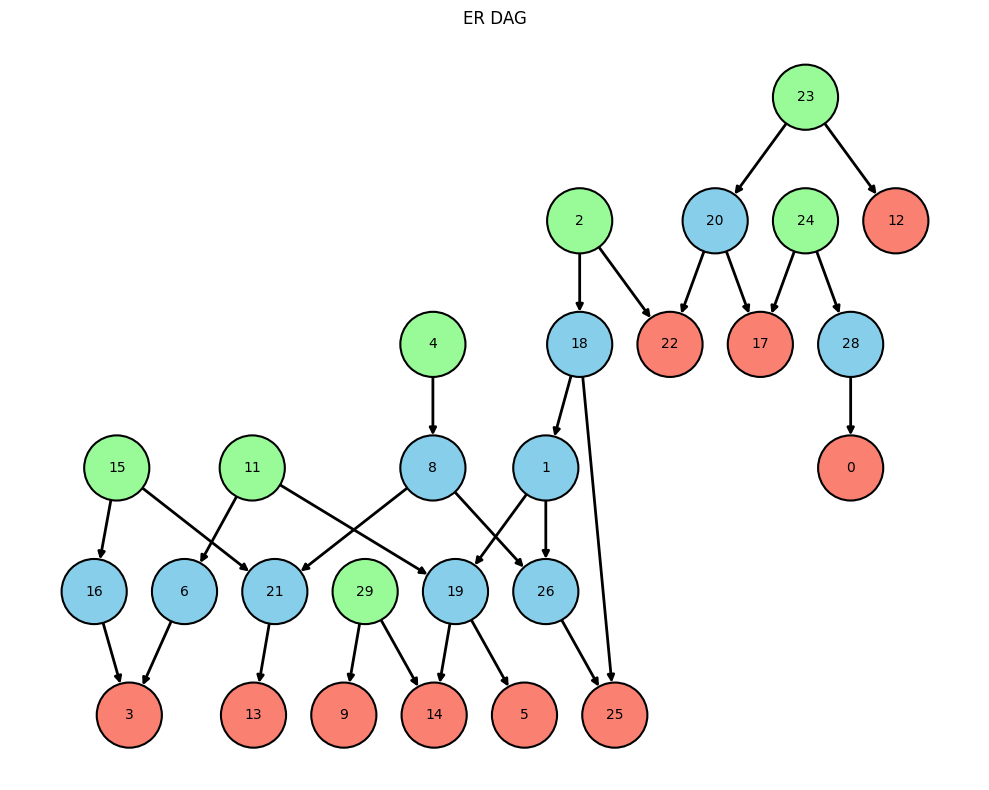

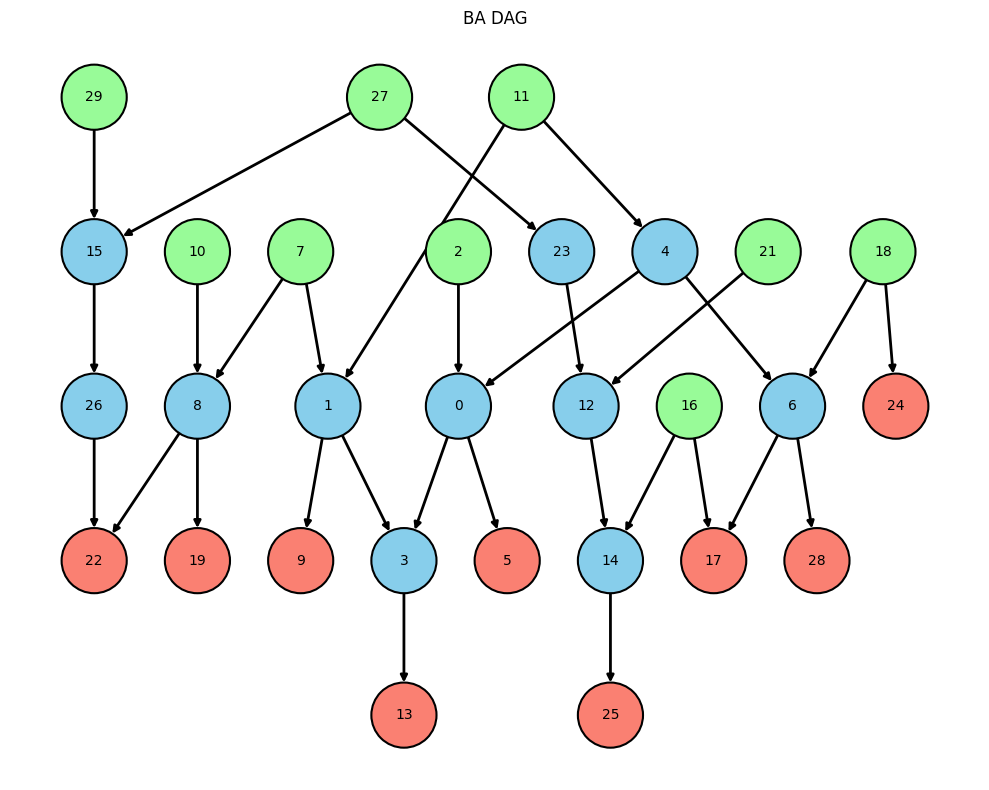

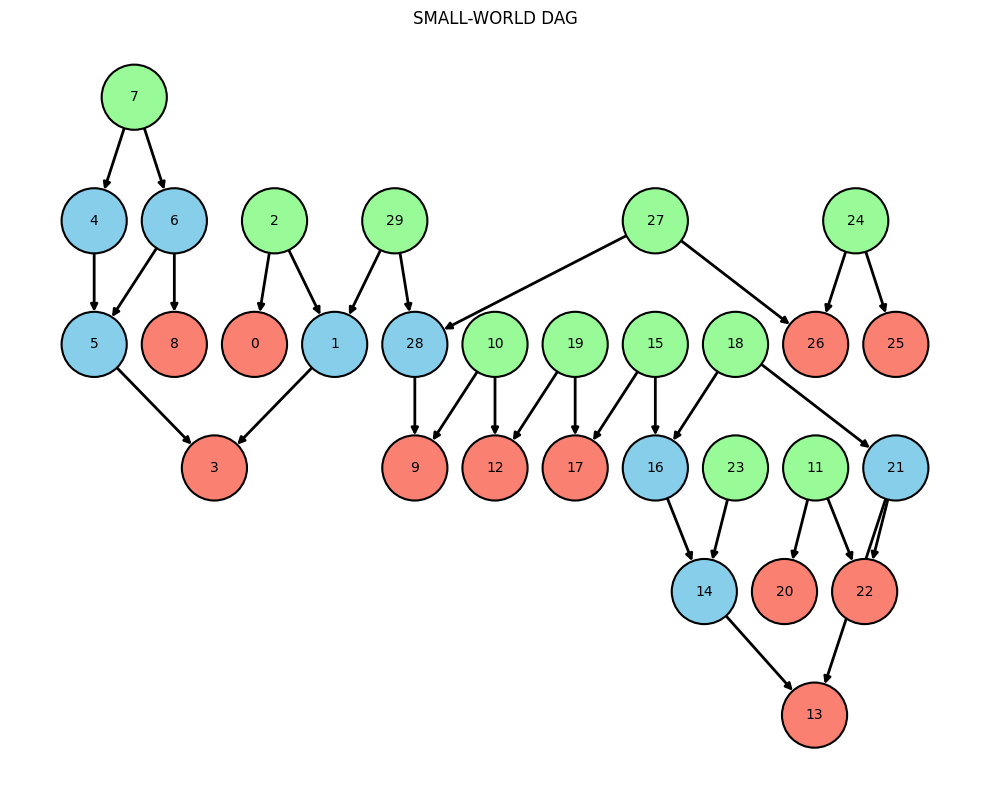

In [5]:
for fam in ["er", "ba", "small-world"]:
    dag, topo, info = sample_dag_family_with_caps(
        n_nodes=30,
        family=fam,
        seed=123,
        max_indeg=2,
        max_outdeg=2,
    )
    visualize_graph(dag, title=f"{fam.upper()} DAG")
    print(
        fam,
        "| edges:", dag.number_of_edges(),
        "| max_in:", max(dict(dag.in_degree()).values()),
        "| max_out:", max(dict(dag.out_degree()).values()),
    )

In [ ]:
dag, topo, info = sample_er_dag(n_nodes=30, seed=1, p_edge=0.2, max_indeg=2, max_outdeg=2)
# dag, topo, info = sample_ba_dag(n_nodes=10, seed=1, m=2, max_indeg=2, max_outdeg=2)

node_cpd, cpd_info = build_node_cpds_from_dag(
    dag,
    topo=topo,
    seed_params=2,
    root_p=0.5,
    p_copy_flip=0.05,
    p_syn=0.3,
    sharpness=12.0,
    gate_types=("OR","AND","NAND","NOR"),
)

df, dag_str, node_spec, meta = simulate_from_dag_cpds(
    dag,
    node_cpd,
    n_samples=5000,
    seed_data=3,
    p_flip_global=0.02,   # optional extra measurement noise
    topo=topo,
)


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network visualisation'}>)

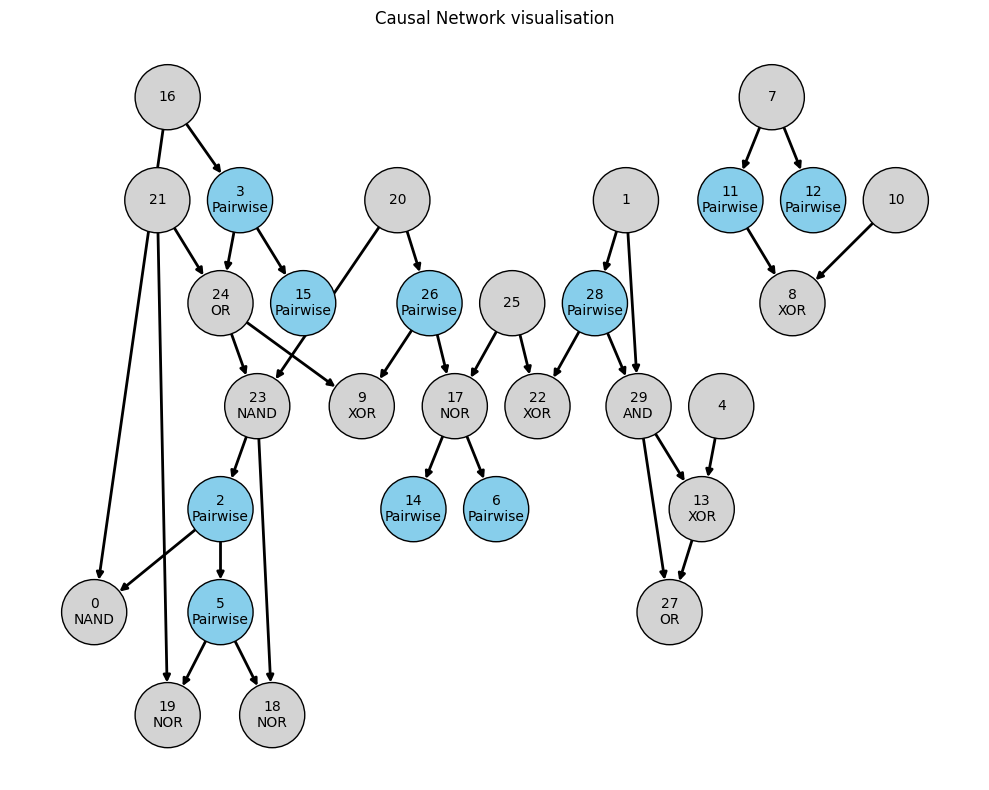

In [8]:
visualize_network_labels(meta)

In [9]:
meta

,Combs,Type
0,"[16, 3]",Pairwise
1,"[1, 28]",Pairwise
2,"[3, 15]",Pairwise
3,"[7, 11]",Pairwise
4,"[3, 21, 24]",OR
5,"[1, 28, 29]",AND
6,"[20, 26]",Pairwise
7,"[20, 24, 23]",NAND
8,"[23, 2]",Pairwise
9,"[25, 26, 17]",NOR


### Test Benchmarks

In [39]:
from algorithms.benchmark import run_hc, run_ea
from metrics.synergy import find_synergistic_triplets
from metrics.graph import *

In [33]:
learned_dag, score = run_hc(
    df,)

In [35]:
evaluate_colliders(meta, learned_dag,)

{'TP (Found Colliders)': 3,
 'FP (Extra Colliders)': 5,
 'FN (Missing Colliders )': 1,
 'TP (Synergistic Colliders Found)': 0,
 'FN (Missing Synergistic Colliders)': 1,
 'Precision (Collider)': 0.375,
 'Recall (Collider)': 0.75,
 'F1 (Collider)': 0.5,
 'Recall (Synergy)': 0.0,
 'TP (Pairwise Colliders Found)': 3,
 'FN (Missing Pairwise Colliders)': 0,
 'Recall (Pairwise)': 1.0}

In [ ]:
triplets = find_synergistic_triplets(df)


In [54]:
learned_ea, score_ea = run_ea(
    df,
    population_size=30,
    generations=5,
    final_greedy=True,
    informed_ratio=1,
    synergy_triplets=triplets,)

In [55]:
evaluate_colliders(metadata_df=meta, learned_graph=learned_ea)

{'TP (Found Colliders)': 1,
 'FP (Extra Colliders)': 0,
 'FN (Missing Colliders )': 3,
 'TP (Synergistic Colliders Found)': 1,
 'FN (Missing Synergistic Colliders)': 0,
 'Precision (Collider)': 1.0,
 'Recall (Collider)': 0.25,
 'F1 (Collider)': 0.4,
 'Recall (Synergy)': 1.0,
 'TP (Pairwise Colliders Found)': 0,
 'FN (Missing Pairwise Colliders)': 3,
 'Recall (Pairwise)': 0.0}